<a href="https://colab.research.google.com/github/PhyoThor/CSIS-4260-Special_Topic_In_Data_Analytics-/blob/main/industry_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance --quiet

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import time
from datetime import datetime, timedelta

In [ ]:
#Define Sector ETFs and their Respectie industries
# This dictionary maps SPDR sector ETFs to their respective industry names.
# Each ETF represents a different industry in the S&P 500.

sector_etfs = {
    "XLC": "Communication Services",
    "XLE": "Energy",
    "XLF": "Financials",
    "XLI": "Industrials",
    "XLK": "Technology",
    "XLB": "Materials",
    "XLRE": "Real Estate",
    "XLU": "Utilities",
    "XLV": "Healthcare",
    "XLY": "Consumer Discretionary"
}

#Define time range(last 5 years)
end_date = datetime.today().strftime('%Y-%m-%d')
start_date = (datetime.today() - timedelta(days=5*365)).strftime('%Y-%m-%d')

#Fecth stock data for each sector ETF
sector_performance = {}

for etf, industry in sector_etfs.items():
  print(f"Fetching data for {industry} ({etf})...")  # Debugging output

  try:
      industry_stock_data = yf.download(etf, start=start_date, end=end_date)

      if industry_stock_data.empty:
          print(f"No data found for {industry} ({etf}). Skipping...\n")
          continue

      #Calculate 5-year return
      initial_price = industry_stock_data["Close"].iloc[0]
      latest_price = industry_stock_data["Close"].iloc[-1]
      percent_change = ((latest_price - initial_price) / initial_price) * 100

      #Store results
      sector_performance[industry] = percent_change.iloc[0] #Store the numeric value

      #Print formatted output
      print(f"{industry} ({etf}): {percent_change.iloc[0]:.2f}% return in 5 years\n")

  except Exception as e:
      print(f"Error fetching data for {industry} ({etf}): {e}\n")
      sector_performance[industry] = float('nan')
      time.sleep(2)

df_performance = pd.DataFrame.from_dict(sector_performance, orient='index', columns=["5-Year Return(%)"])
df_performance = df_performance.sort_values(by="5-Year Return(%)", ascending=False)

df_performance_top10= df_performance.head(10)
print(df_performance_top10)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Fetching data for Communication Services (XLC)...
Communication Services (XLC): 149.60% return in 5 years

Fetching data for Energy (XLE)...
Energy (XLE): 340.39% return in 5 years

Fetching data for Financials (XLF)...
Financials (XLF): 186.05% return in 5 years

Fetching data for Industrials (XLI)...
Industrials (XLI): 178.78% return in 5 years

Fetching data for Technology (XLK)...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Technology (XLK): 210.82% return in 5 years

Fetching data for Materials (XLB)...
Materials (XLB): 136.47% return in 5 years

Fetching data for Real Estate (XLRE)...
Real Estate (XLRE): 82.64% return in 5 years

Fetching data for Utilities (XLU)...
Utilities (XLU): 92.89% return in 5 years

Fetching data for Healthcare (XLV)...
Healthcare (XLV): 101.04% return in 5 years

Fetching data for Consumer Discretionary (XLY)...


[*********************100%***********************]  1 of 1 completed


Consumer Discretionary (XLY): 129.99% return in 5 years

                        5-Year Return(%)
Energy                        340.386493
Technology                    210.820940
Financials                    186.046686
Industrials                   178.784223
Communication Services        149.604476
Materials                     136.474783
Consumer Discretionary        129.994209
Healthcare                    101.044235
Utilities                      92.892145
Real Estate                    82.642334


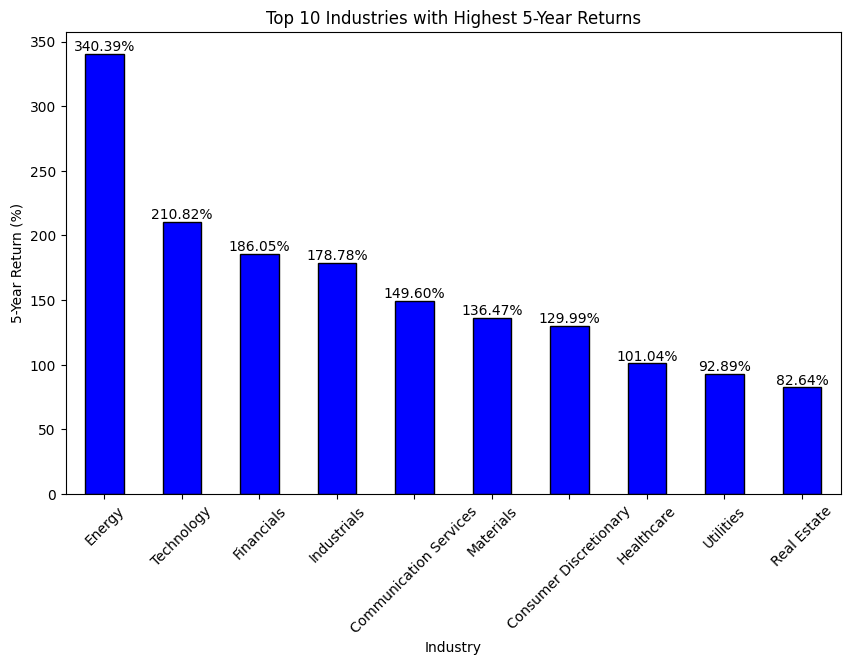

In [ ]:
plt.figure(figsize=(10,6))
bars = df_performance_top10["5-Year Return(%)"].plot(kind="bar", color='blue', edgecolor='black')
plt.title("Top 10 Industries with Highest 5-Year Returns")
plt.xlabel("Industry")
plt.ylabel("5-Year Return (%)")
plt.xticks(rotation=45)

# Add data labels to the bars
for bar in bars.patches:
    bars.annotate(f'{bar.get_height():.2f}%',
                   (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                   ha='center', va='bottom')

plt.show()